In [ ]:
print("Hello")

Hello


In [ ]:
!pip install pypdf

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
from pypdf import PdfReader

reader = PdfReader("file.pdf")

xml = "<document>\n"

for i,page in enumerate(reader.pages):
    xml += f"<page id='{i+1}'>"
    xml += page.extract_text()
    xml += "</page>\n"
xml += "<document>"

open("output.xml", "w").write(xml)

UnicodeEncodeError: 'charmap' codec can't encode character '\u25a0' in position 33597: character maps to <undefined>

In [5]:
from pypdf import PdfReader

reader = PdfReader("file.pdf")

xml = "<document>\n"

for i, page in enumerate(reader.pages):

    xml += f"<page id='{i+1}'>"
    xml += page.extract_text()
    xml += "</page>\n"

xml += "</document>"

open("output.xml", "w").write(xml)

UnicodeEncodeError: 'charmap' codec can't encode character '\u25a0' in position 33597: character maps to <undefined>

In [8]:
from pypdf import PdfReader

reader = PdfReader("file.pdf")

xml = "<document>\n"

for i, page in enumerate(reader.pages, start=1):
    xml += f"<page id='{i}'>\n"

    text = page.extract_text()
    if text:
        xml += text

    xml += "\n</page>\n"

xml += "</document>"

with open("output1.xml", "w", encoding="utf-8") as f:
    f.write(xml)

In [6]:
colors = ["red", "blue"]

for i, color in enumerate(colors):
    print(i, color)

0 red
1 blue


In [7]:
from pypdf import PdfReader

reader = PdfReader("file.pdf")

with open("output.xml", "w", encoding="utf-8") as f:

    f.write("<document>\n")

    for i, page in enumerate(reader.pages, start=1):

        text = page.extract_text()

        f.write(f"<page id='{i}'>\n")
        f.write(text if text else "")
        f.write("\n</page>\n")

    f.write("</document>")

https://www.youtube.com/post/Ugkx0wtlvfUvDH4bDu9ynlhz0SELZTQHXd5f


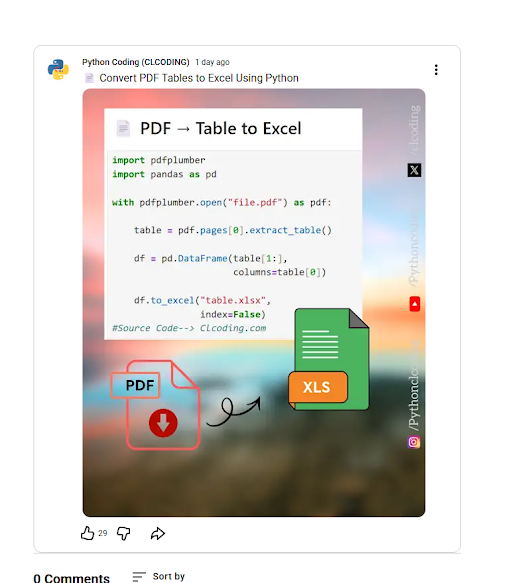


In [1]:
!pip install pdfplumber

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/6.6 MB ? eta -:--:--
   ---------------------------------------- 6.6/6.6 MB 86.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [pdfminer.six]
   ---------------------------------------- 0/2 [pdfminer.six]
   ---------------------------------------- 0/2 [pdfminer.six]
   ---------------------------------------- 0/2 [pdfminer.six]
   ---------------------------------------- 0/2 [pdfminer.six]
   ---------------------------------------- 0/2 [pdfminer.six]
   -------------------- ------------------- 1/2 [pdfplumber]
   -------------------- ------------------- 1/2 [pdfplumber]
   -------------------- ------------------- 1/2 [pdfplumber]
   ---------------------------------------- 2/2 [pdfplumber]




[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pdfplumber
import pandas as pd

with pdfplumber.open("file.pdf") as pdf:
    table = pdf.pages[0].extract_table()
    df = pd.DataFrame(table[1:],columns=table[0])
    df.to_excel("table.xlsx", index=False)

TypeError: 'NoneType' object is not subscriptable

The error is:

```python
TypeError: 'NoneType' object is not subscriptable
```

It occurs on this line:

```python
df = pd.DataFrame(table[1:], columns=table[0])
```

### Why it happens

`pdf.pages[0].extract_table()` returned **None** instead of a table.

So:

```python
table = pdf.pages[0].extract_table()
print(table)
```

is effectively:

```python
table = None
```

Then Python tries to do:

```python
table[1:]
```

which becomes:

```python
None[1:]
```

and causes the error.

***

## Verify first

Add a print statement:

```python
import pdfplumber

with pdfplumber.open("file.pdf") as pdf:
    table = pdf.pages[0].extract_table()
    print(table)
```

If the output is:

```python
None
```

then no table was detected on page 1.

***

## Safe version

```python
import pdfplumber
import pandas as pd

with pdfplumber.open("file.pdf") as pdf:
    table = pdf.pages[0].extract_table()

    if table:
        df = pd.DataFrame(table[1:], columns=table[0])
        df.to_excel("table.xlsx", index=False)
        print("Table exported successfully")
    else:
        print("No table found on page 1")
```

***

## If the PDF has multiple pages

Many PDFs contain tables on pages other than page 1.

```python
import pdfplumber
import pandas as pd

with pdfplumber.open("file.pdf") as pdf:
    for i, page in enumerate(pdf.pages):
        table = page.extract_table()

        if table:
            df = pd.DataFrame(table[1:], columns=table[0])
            df.to_excel(f"table_page_{i+1}.xlsx", index=False)
            print(f"Table found on page {i+1}")
```

***

## Common reason in network/operations PDFs

If the PDF is:

* A scanned image
* A screenshot saved as PDF
* A report generated as an image

then `pdfplumber` **cannot detect a table** and returns `None`.

Check:

```python
with pdfplumber.open("file.pdf") as pdf:
    page = pdf.pages[0]
    print(page.extract_text())
```

If this also returns `None` or very little text, the PDF is image-based.

For image PDFs, use OCR:

```python
import pdfplumber
import pytesseract
from PIL import Image
```

or

```python
import camelot
```

for structured tables.

***

## Better debugging

Run this:

```python
import pdfplumber

with pdfplumber.open("file.pdf") as pdf:
    for i, page in enumerate(pdf.pages):
        print(f"\nPage {i+1}")

        text = page.extract_text()
        print("Text found:", text is not None)

        table = page.extract_table()
        print("Table found:", table is not None)
```

This will immediately tell you:

* Whether text exists
* Whether a table exists
* Which page contains the table

Most likely, in your case, `extract_table()` is returning **None** because the table is not being recognized on page 1 or the PDF is image-based.


In [3]:
import pdfplumber

with pdfplumber.open("file.pdf") as pdf:
    table = pdf.pages[0].extract_table()
    print(table)

None


In [4]:
import pdfplumber
import pandas as pd

with pdfplumber.open("file.pdf") as pdf:
    table = pdf.pages[0].extract_table()

    if table:
        df = pd.DataFrame(table[1:], columns=table[0])
        df.to_excel("table.xlsx", index=False)
        print("Table exported successfully")
    else:
        print("No table found on page 1")

No table found on page 1


In [5]:
import pdfplumber
import pandas as pd

with pdfplumber.open("file.pdf") as pdf:
    for i, page in enumerate(pdf.pages):
        table = page.extract_table()

        if table:
            df = pd.DataFrame(table[1:], columns=table[0])
            df.to_excel(f"table_page_{i+1}.xlsx", index=False)
            print(f"Table found on page {i+1}")

ModuleNotFoundError: No module named 'openpyxl'

In [6]:
import pdfplumber

with pdfplumber.open("file.pdf") as pdf:
    for i, page in enumerate(pdf.pages):
        print(f"\nPage {i+1}")

        text = page.extract_text()
        print("Text found:", text is not None)

        table = page.extract_table()
        print("Table found:", table is not None)


Page 1
Text found: True
Table found: False

Page 2
Text found: True
Table found: False

Page 3
Text found: True
Table found: False

Page 4
Text found: True
Table found: False

Page 5
Text found: True
Table found: False

Page 6
Text found: True
Table found: False

Page 7
Text found: True
Table found: False

Page 8
Text found: True
Table found: False

Page 9
Text found: True
Table found: False

Page 10
Text found: True
Table found: False

Page 11
Text found: True
Table found: False

Page 12
Text found: True
Table found: False

Page 13
Text found: True
Table found: False

Page 14
Text found: True
Table found: False

Page 15
Text found: True
Table found: False

Page 16
Text found: True
Table found: False

Page 17
Text found: True
Table found: False

Page 18
Text found: True
Table found: False

Page 19
Text found: True
Table found: False

Page 20
Text found: True
Table found: False

Page 21
Text found: True
Table found: False

Page 22
Text found: True
Table found: False

Page 23
Text found